In [1]:
# Set the config path here, need to restart the notebook after changing this
config_file = '../configs/example_config.yaml'

# Imports

In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spice
spice.load_config(config_file)
from spice import config, directories, data_loaders, plot
from spice.data_loaders import resolve_data_file, load_final_events

plt.rcParams.update({
    'legend.fontsize': 'x-large',
    'figure.figsize': (15, 5),
    'axes.labelsize': 'x-large',
    'axes.titlesize': 20,
    'figure.titlesize': 20,
    'xtick.labelsize':'x-large',
    'ytick.labelsize':'x-large'
    })

plotting_params = {
    'WIDTH_FULL': 25,
    'WIDTH_HALF': 25/2,
    'ASPECT_RATIO': 4/3,
    'FONTSIZE_LARGE': 14,
    'FONTSIZE_MEDIUM': 10,
    'FONTSIZE_SMALL': 8,
    'FONTSIZE_TINY': 5,
    'LINEWIDTH': 1,
    'MARKERSIZE_SMALL': 1,
    'MARKERSIZE_MEDIUM': 2,
    'MARKERSIZE_LARGE': 3,
    'LINEWIDTH_SMALL': 0.5}

CHROM_LENS = data_loaders.load_chrom_lengths()
CHROMS = list(CHROM_LENS.keys())
CENTROMERES = data_loaders.load_centromeres()

%load_ext autoreload
%autoreload 2
%matplotlib inline

# Load data and results

In [3]:
chrom_segments_file = resolve_data_file()
chrom_segments = pd.read_csv(chrom_segments_file, sep='\t',
                             index_col=['sample_id', 'chrom', 'allele']).sort_index()
final_events_df = load_final_events()
summary = pd.read_csv(
    os.path.join(directories['results_dir'], config['name'], 'summary.tsv'), sep='\t',
    index_col='id')

In [4]:
True ^ False

True

# Plot inferred events

## Per sample

### Normal

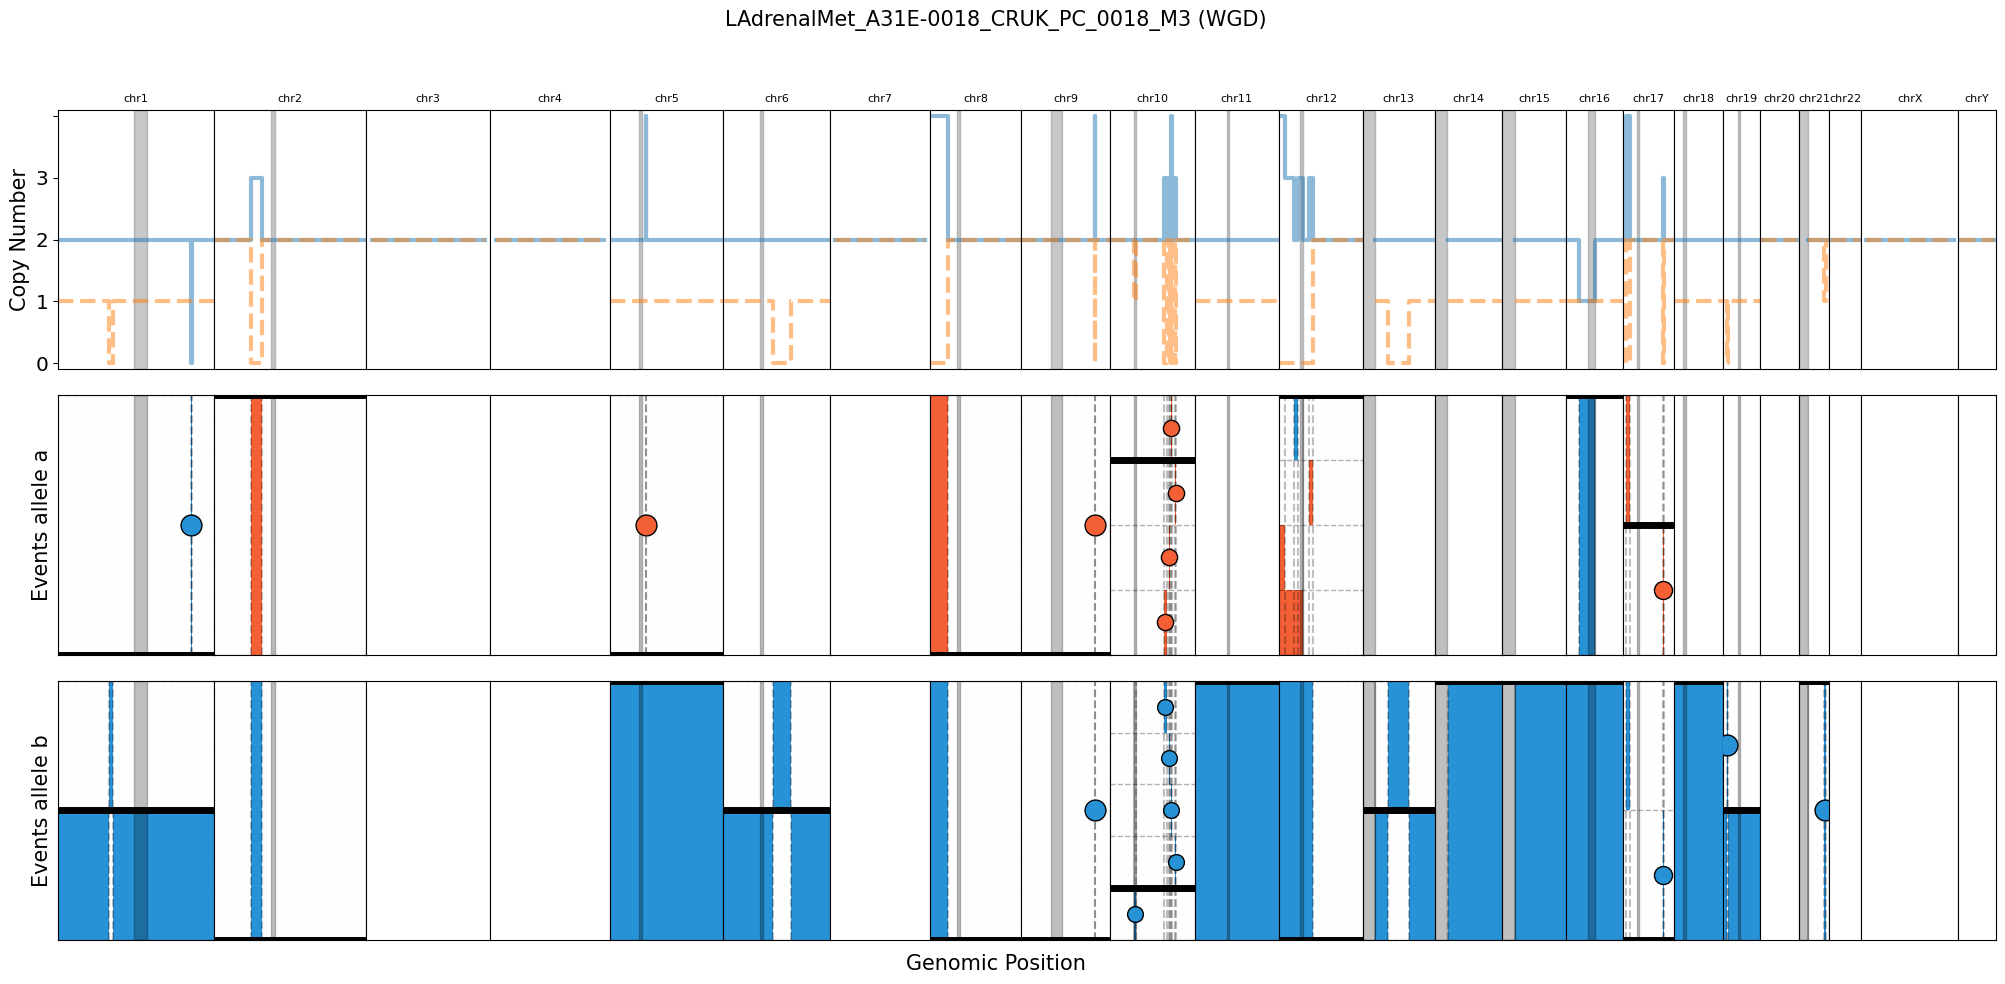

In [5]:
cur_sample = 'LAdrenalMet_A31E-0018_CRUK_PC_0018_M3'

fig, axs = plot.plot_inferred_events_per_sample(
    cur_sample,
    chrom_segments,
    final_events_df,
    unit_size=False,
)

### Copy-number segments instead of genomic position

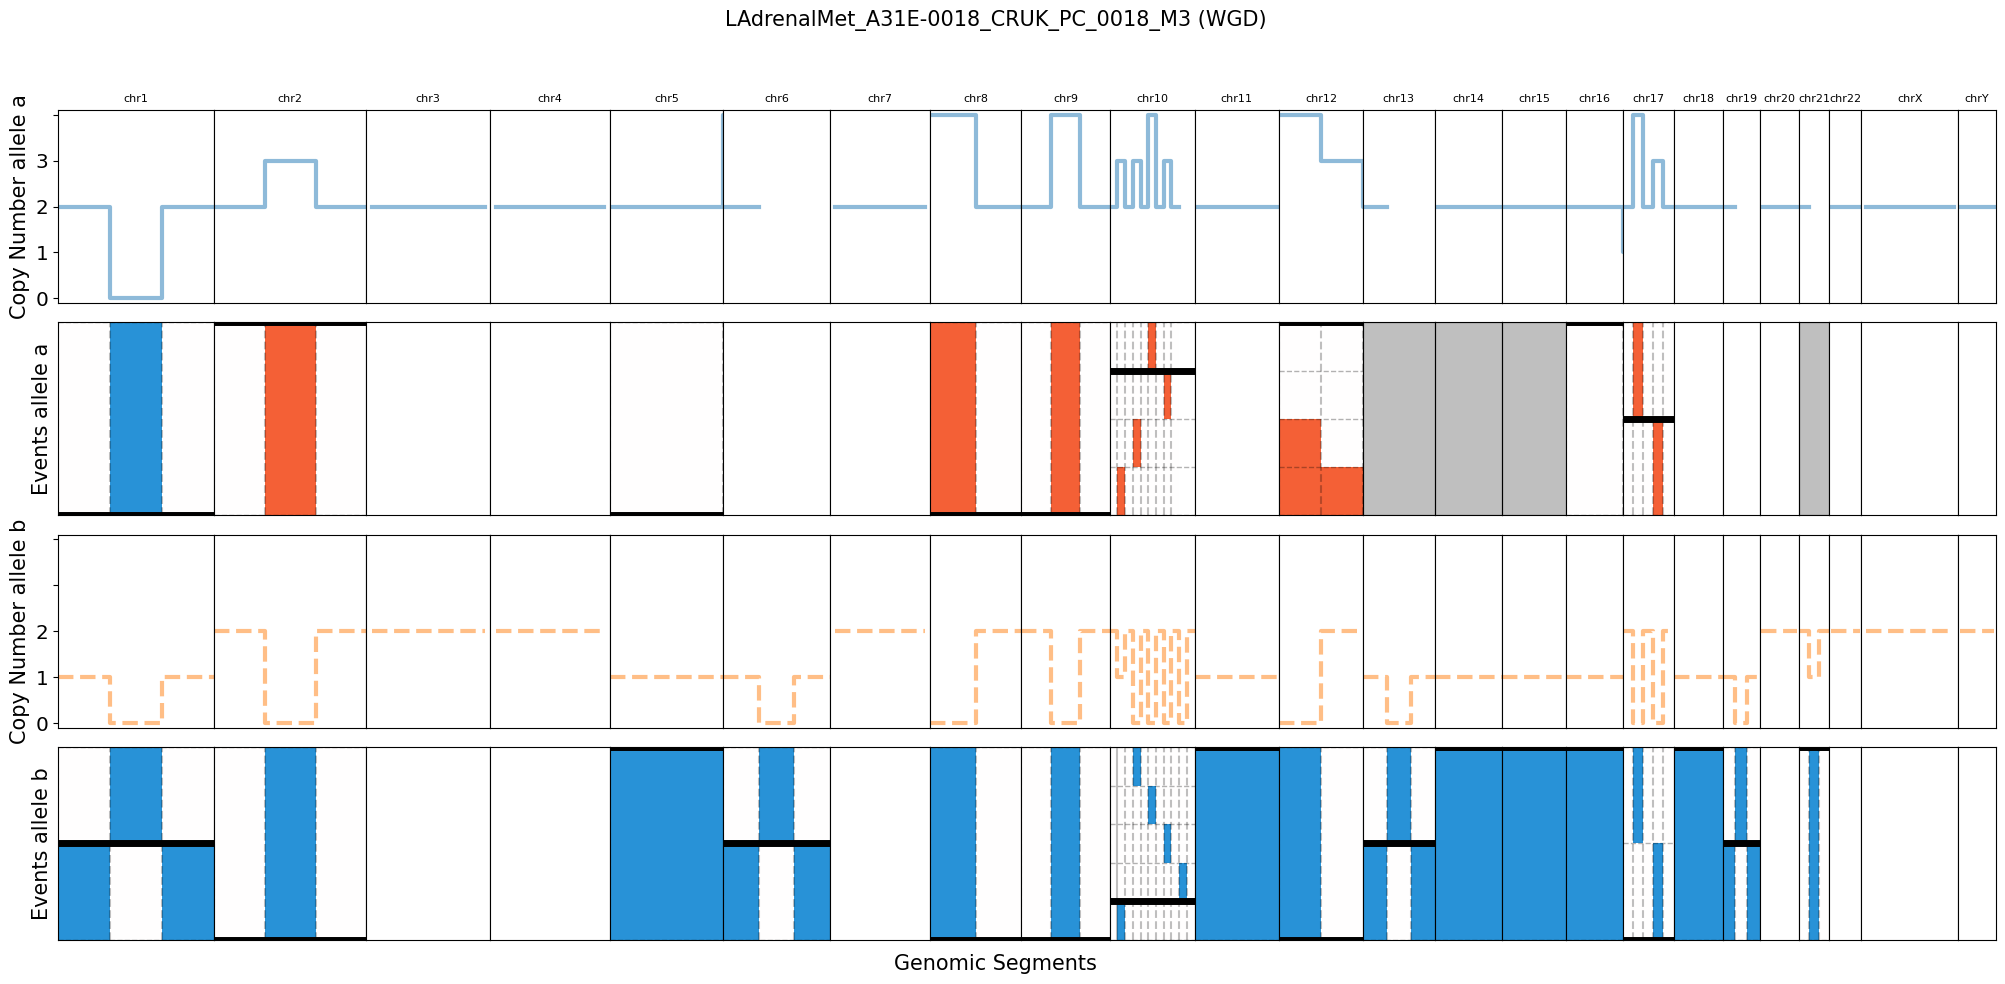

In [6]:
cur_sample = 'LAdrenalMet_A31E-0018_CRUK_PC_0018_M3'

fig, axs = plot.plot_inferred_events_per_sample(
    cur_sample,
    chrom_segments,
    final_events_df,
    unit_size=True,
)

## Per ID

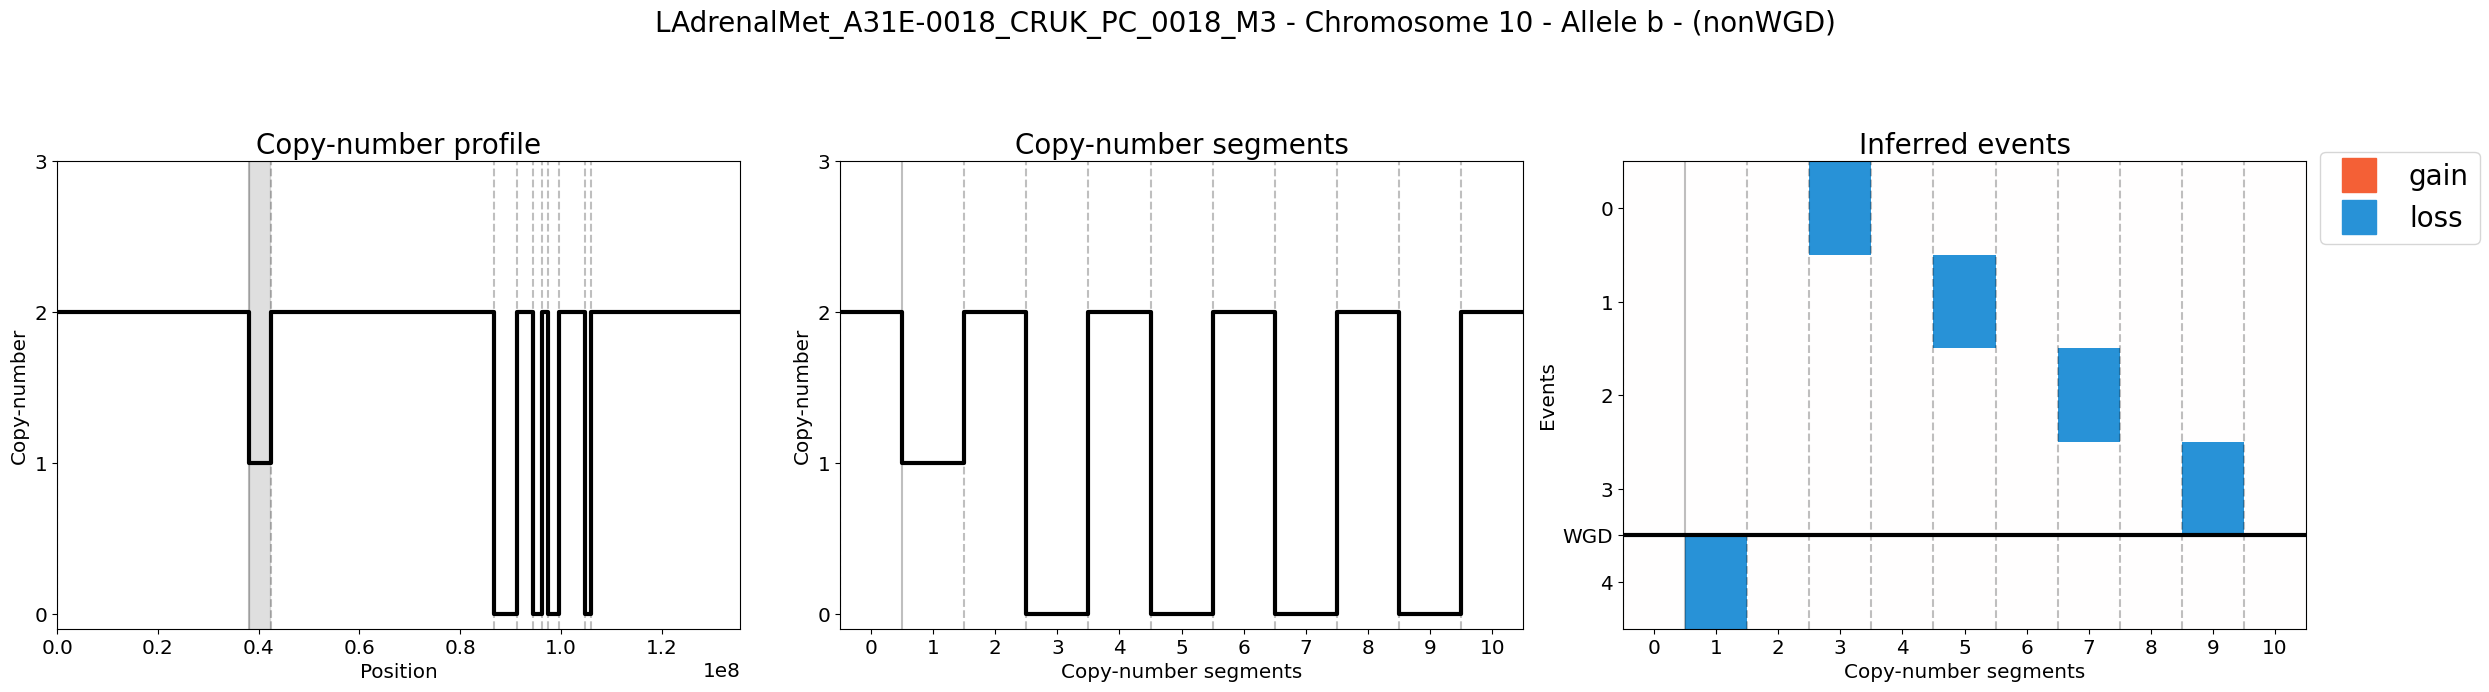

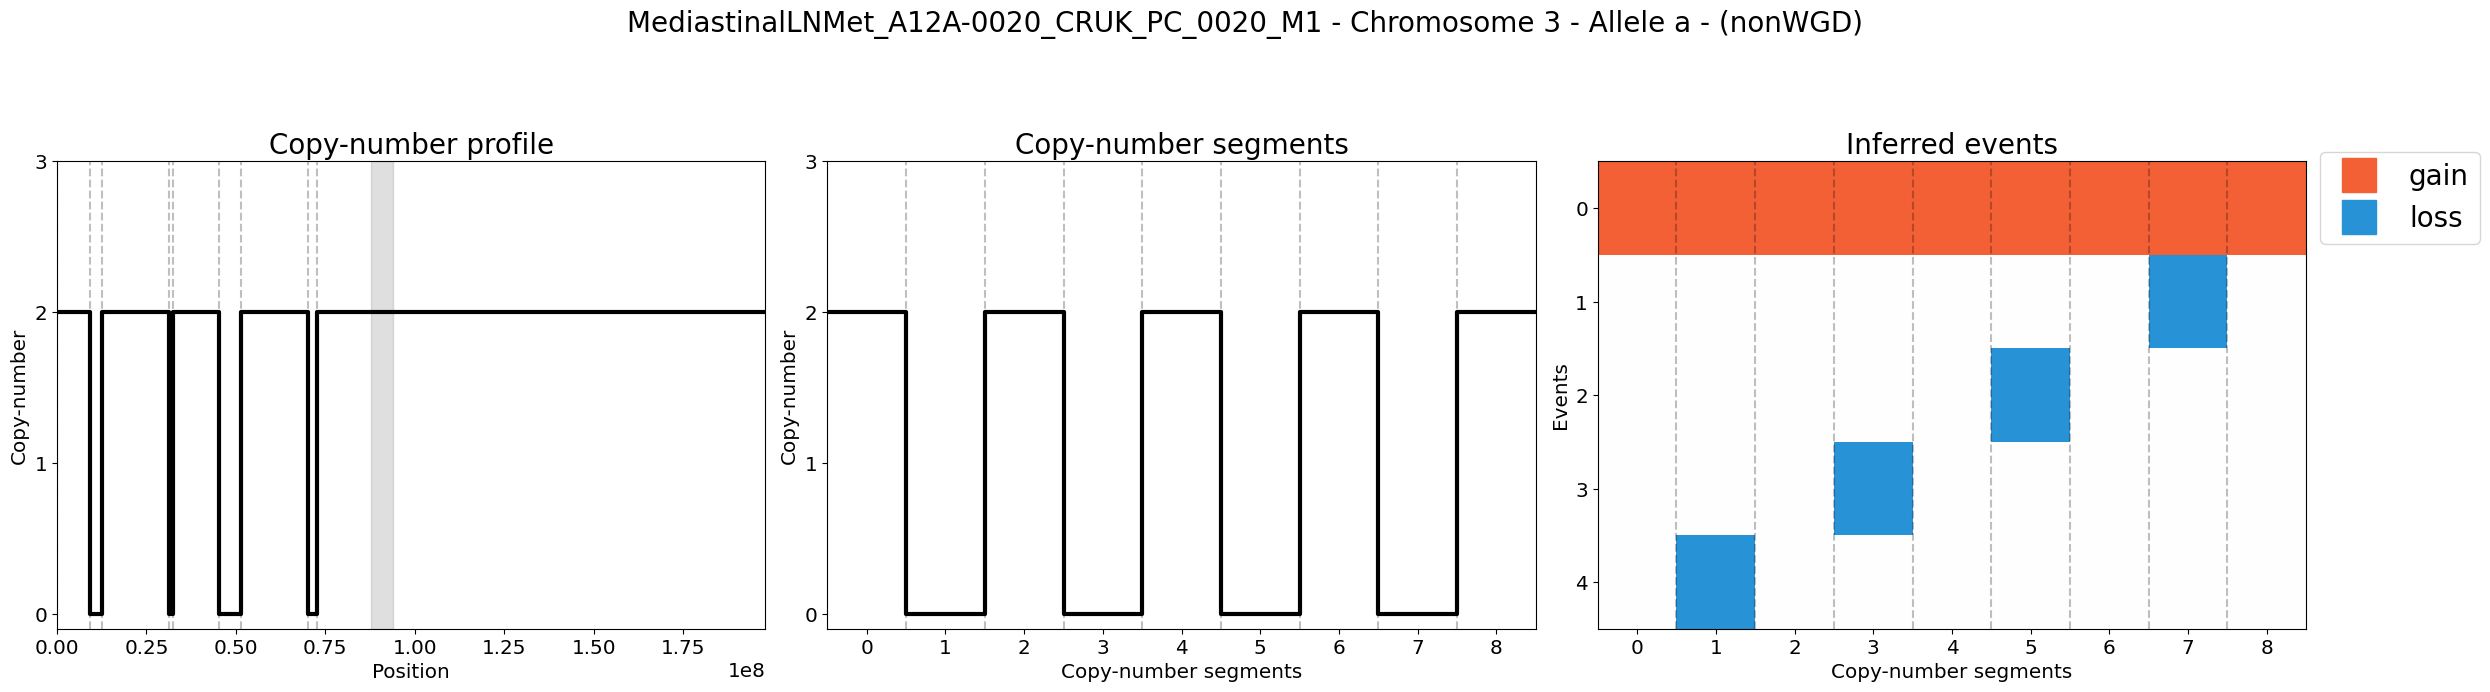

In [7]:
cur_ids = [
    'LAdrenalMet_A31E-0018_CRUK_PC_0018_M3:chr10:cn_b',
    'MediastinalLNMet_A12A-0020_CRUK_PC_0020_M1:chr3:cn_a',
]
for i, cur_id in enumerate(cur_ids):   
    fig = plot.plot_inferred_events_per_id(
        cur_id, chrom_segments, final_events_df, single_row=True, show_legend=True,
        figsize=(plotting_params['WIDTH_FULL'], 1.25/5*plotting_params['WIDTH_FULL']),
        lw=3, markersize=4
    )
    plt.tight_layout()
    plt.show()

# Aggregated events

**Coming soon**